# Part 1 — What Types of Apps to BUILD (Original Ideas)

**Goal:** Find app categories where demand is proven but no one has nailed the execution.  
These are the best opportunities to build something *new and better* — not a clone.

**Signals we look for:**
- High installs (demand exists) but low average rating (execution is bad across the board)
- Categories growing in 2026 scraped data (new apps gaining traction quickly)
- Niches with few apps but high average installs per app (low competition, high demand)
- Categories where the rating distribution is wide — top apps are mediocre, no clear winner

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import warnings
from pathlib import Path
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

TAPIVE_RELATIVE = 'data_my_copy/google-play-dataset-by-tapivedotcom.csv/google-play-dataset-by-tapivedotcom.csv'
APPS26_RELATIVE = 'data/scraped_2026/apps.csv'

def find_project_root():
    candidates = [Path().resolve()]
    p = Path().resolve()
    for _ in range(10):
        p = p.parent
        candidates.append(p)
    for c in candidates:
        if (c / TAPIVE_RELATIVE).exists():
            return c
    raise FileNotFoundError(f'Cannot find Tapive CSV. Searched: {candidates}')

ROOT = find_project_root()
TAPIVE_PATH = str(ROOT / TAPIVE_RELATIVE)
APPS_2026_PATH = str(ROOT / APPS26_RELATIVE)
print(f'Project root: {ROOT}')

print('Loading datasets...')
tap = pd.read_csv(TAPIVE_PATH, low_memory=False)
apps26 = pd.read_csv(APPS_2026_PATH, low_memory=False)
print(f'Tapive: {len(tap):,} apps')
print(f'2026 scraped: {len(apps26):,} apps')

Project root: D:\Projects\play-store-analysis-github
Loading datasets...


Tapive: 3,451,063 apps
2026 scraped: 11,176 apps


In [2]:
# --- Clean Tapive dataset ---
tap['minInstalls'] = pd.to_numeric(tap['minInstalls'], errors='coerce')
tap['score'] = pd.to_numeric(tap['score'], errors='coerce')
tap['ratings'] = pd.to_numeric(tap['ratings'], errors='coerce')

# Keep only apps with meaningful data
tap_clean = tap.dropna(subset=['genre', 'score', 'minInstalls']).copy()
tap_clean = tap_clean[tap_clean['minInstalls'] >= 1000]   # at least 1k installs
tap_clean = tap_clean[tap_clean['score'] > 0]
print(f'Tapive cleaned: {len(tap_clean):,} apps')

# --- Clean 2026 dataset ---
apps26['min_installs'] = pd.to_numeric(apps26['min_installs'], errors='coerce')
apps26['score'] = pd.to_numeric(apps26['score'], errors='coerce')
apps26['ratings'] = pd.to_numeric(apps26['ratings'], errors='coerce')

apps26_clean = apps26.dropna(subset=['genre', 'score', 'min_installs']).copy()
apps26_clean = apps26_clean[apps26_clean['min_installs'] >= 1000]
apps26_clean = apps26_clean[apps26_clean['score'] > 0]
print(f'2026 cleaned: {len(apps26_clean):,} apps')

Tapive cleaned: 411,453 apps


2026 cleaned: 7,875 apps


In [3]:
# ── BIG-TECH SEGMENTATION ───────────────────────────────────────────────────
# We keep big-tech apps in the dataset for context/benchmarking, but flag them.
# All opportunity analysis runs on indie_* (non-big-tech) so results are realistic.
BIG_TECH_PATTERNS = [
    'google', 'meta platforms', 'facebook', 'instagram', 'whatsapp',
    'microsoft', 'amazon', 'netflix', 'spotify', 'twitter', 'x corp',
    'tiktok', 'bytedance', 'snapchat', 'linkedin', 'adobe', 'apple inc',
    'samsung', 'huawei', 'xiaomi', 'alibaba', 'tencent', 'baidu',
    'mozilla', 'opera', 'yahoo', 'uber', 'airbnb', 'paypal', 'ebay',
    'booking.com', 'expedia', 'tripadvisor',
]

def is_big_tech(dev_name):
    if pd.isna(dev_name):
        return False
    d = str(dev_name).lower()
    return any(p in d for p in BIG_TECH_PATTERNS)

tap_clean['is_big_tech'] = tap_clean['developer'].apply(is_big_tech)
apps26_clean['is_big_tech'] = apps26_clean['developer'].apply(is_big_tech)

# Separate views — tap_clean / apps26_clean still have everything for reference
tap_indie    = tap_clean[~tap_clean['is_big_tech']].copy()
apps26_indie = apps26_clean[~apps26_clean['is_big_tech']].copy()

n_bt_tap = tap_clean['is_big_tech'].sum()
n_bt_26  = apps26_clean['is_big_tech'].sum()
print(f'Tapive — big-tech apps: {n_bt_tap:,}  |  indie apps: {len(tap_indie):,}')
print(f'2026   — big-tech apps: {n_bt_26:,}  |  indie apps: {len(apps26_indie):,}')

# Show which categories big tech dominates (for reference)
bt_dominance = tap_clean.groupby('genre').apply(
    lambda g: g['is_big_tech'].sum() / len(g) * 100
).reset_index(name='pct_big_tech')
bt_dominance = bt_dominance.sort_values('pct_big_tech', ascending=False)
print('\nTop categories by big-tech share (context only — these skew raw numbers):')
print(bt_dominance[bt_dominance['pct_big_tech'] > 0].head(15).to_string(index=False))
# ─────────────────────────────────────────────────────────────────────────────

Tapive — big-tech apps: 1,380  |  indie apps: 410,073
2026   — big-tech apps: 190  |  indie apps: 7,685



Top categories by big-tech share (context only — these skew raw numbers):
                  genre  pct_big_tech
       Libraries & Demo      1.248266
               Business      1.227669
          Communication      0.821580
                  Tools      0.821184
                 Events      0.682594
              Parenting      0.628931
           Productivity      0.552821
                 Social      0.546999
         Travel & Local      0.524674
Video Players & Editors      0.521966
               Shopping      0.503950
              Education      0.471716
           House & Home      0.450450
      Maps & Navigation      0.433735
                Finance      0.414891


## Signal 1 — High Demand, Low Quality (Tapive 3.4M)
Categories with large install base but the average rating is poor (< 3.8).  
If everyone in the category is bad, a well-built app wins easily.

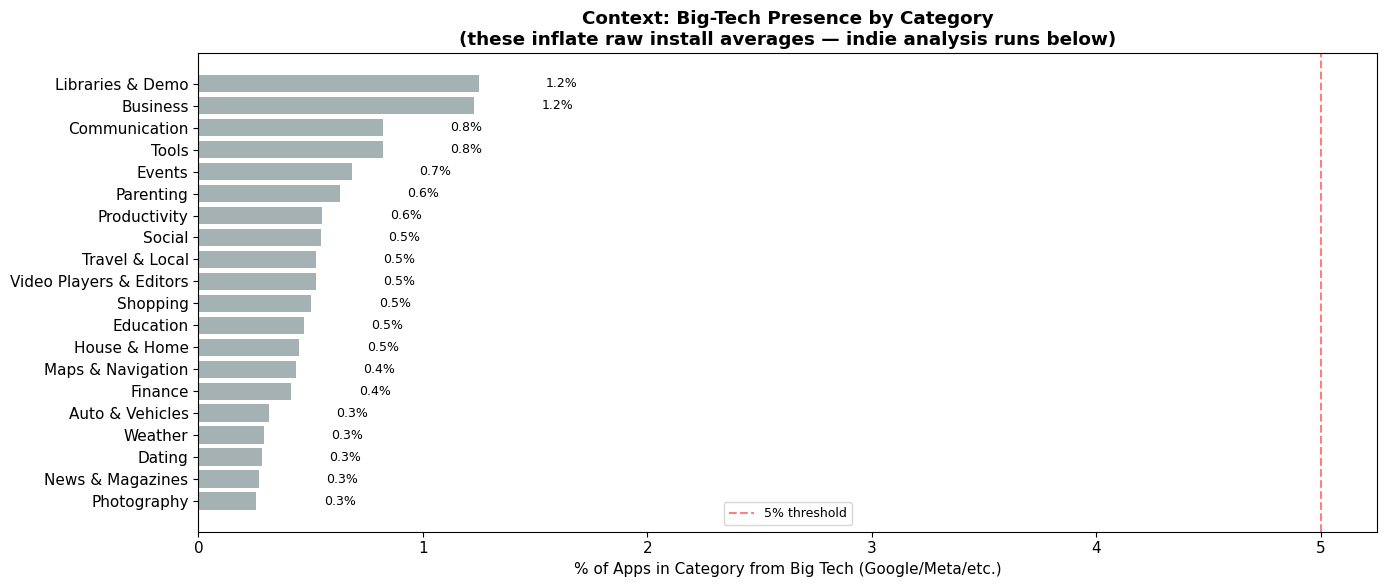

Underserved indie categories (high demand, low quality): 3
                  genre  app_count  avg_score  avg_installs  pct_under_3
Video Players & Editors       4574   3.787293  1.848303e+06    16.309576
             Simulation      13606   3.744121  1.082709e+06    14.126121
      Maps & Navigation       4132   3.775327  6.551077e+05    14.399806


In [4]:
# --- Context: Big-tech install dominance by category ---
fig, ax = plt.subplots(figsize=(14, 6))
bt_plot = bt_dominance[bt_dominance['pct_big_tech'] > 0].head(20).sort_values('pct_big_tech')
bars = ax.barh(bt_plot['genre'], bt_plot['pct_big_tech'], color='#95a5a6', alpha=0.85)
for bar, val in zip(bars, bt_plot['pct_big_tech']):
    ax.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
            f'{val:.1f}%', va='center', fontsize=9)
ax.set_xlabel('% of Apps in Category from Big Tech (Google/Meta/etc.)')
ax.set_title('Context: Big-Tech Presence by Category\n'
             '(these inflate raw install averages — indie analysis runs below)', fontweight='bold')
ax.axvline(5, color='red', linestyle='--', alpha=0.5, label='5% threshold')
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('p1_bigtech_context.png', dpi=150, bbox_inches='tight')
plt.show()

# --- Signal 1: Indie apps — high demand, low quality ---
cat_stats = tap_indie.groupby('genre').agg(
    app_count=('appId', 'count'),
    avg_score=('score', 'mean'),
    median_score=('score', 'median'),
    total_installs=('minInstalls', 'sum'),
    avg_installs=('minInstalls', 'mean'),
    pct_under_3=('score', lambda x: (x < 3.0).mean() * 100)
).reset_index()

cat_stats = cat_stats[cat_stats['app_count'] >= 200]
cat_stats = cat_stats.sort_values('avg_installs', ascending=False)

median_installs = cat_stats['avg_installs'].median()
underserved = cat_stats[
    (cat_stats['avg_installs'] >= median_installs) &
    (cat_stats['avg_score'] < 3.8)
].sort_values('avg_installs', ascending=False)

print(f'Underserved indie categories (high demand, low quality): {len(underserved)}')
print(underserved[['genre','app_count','avg_score','avg_installs','pct_under_3']].to_string(index=False))

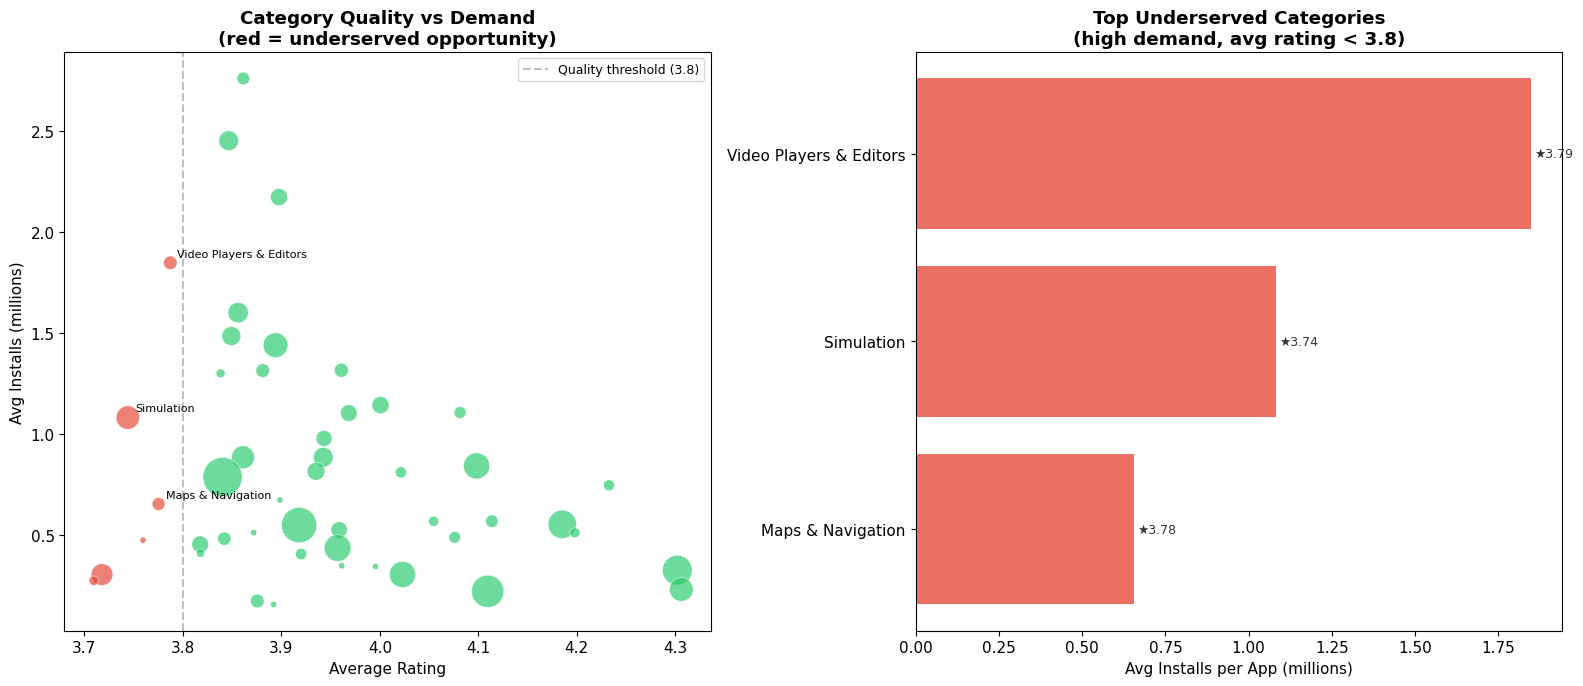

Saved: p1_underserved_categories.png


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Left: scatter — avg_installs vs avg_score, bubble = app_count
ax = axes[0]
sizes = np.clip(cat_stats['app_count'] / cat_stats['app_count'].max() * 800, 20, 800)
colors = ['#e74c3c' if s < 3.8 else '#2ecc71' for s in cat_stats['avg_score']]
scatter = ax.scatter(
    cat_stats['avg_score'], 
    cat_stats['avg_installs'] / 1e6,
    s=sizes, c=colors, alpha=0.7, edgecolors='white', linewidth=0.5
)
ax.axvline(3.8, color='gray', linestyle='--', alpha=0.5, label='Quality threshold (3.8)')
for _, row in underserved.head(8).iterrows():
    ax.annotate(row['genre'], (row['avg_score'], row['avg_installs']/1e6),
                fontsize=8, ha='left', va='bottom',
                xytext=(5, 3), textcoords='offset points')
ax.set_xlabel('Average Rating')
ax.set_ylabel('Avg Installs (millions)')
ax.set_title('Category Quality vs Demand\n(red = underserved opportunity)', fontweight='bold')
ax.legend(fontsize=9)

# Right: top underserved categories bar chart
ax2 = axes[1]
top_u = underserved.head(12).sort_values('avg_installs')
bars = ax2.barh(top_u['genre'], top_u['avg_installs']/1e6, color='#e74c3c', alpha=0.8)
for bar, score in zip(bars, top_u['avg_score']):
    ax2.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
             f'★{score:.2f}', va='center', fontsize=9, color='#333')
ax2.set_xlabel('Avg Installs per App (millions)')
ax2.set_title('Top Underserved Categories\n(high demand, avg rating < 3.8)', fontweight='bold')

plt.tight_layout()
plt.savefig('p1_underserved_categories.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: p1_underserved_categories.png')

## Signal 2 — Low Competition, High Demand (Niche Goldmines)
Categories with fewer apps but high average installs per app.  
Less competition, but users are clearly hungry for what's there.

In [6]:
niche = cat_stats.copy()
niche['demand_supply_ratio'] = niche['avg_installs'] / (niche['app_count'] ** 0.5)
niche_sorted = niche.sort_values('demand_supply_ratio', ascending=False)

print('=== TOP INDIE NICHES: High demand-to-supply ratio ===')
print(niche_sorted[['genre','app_count','avg_installs','avg_score','demand_supply_ratio']].head(20).to_string(index=False))

=== TOP INDIE NICHES: High demand-to-supply ratio ===
                  genre  app_count  avg_installs  avg_score  demand_supply_ratio
                 Racing       4043  2.760629e+06   3.861370         43416.636288
                  Music       1968  1.301343e+06   3.838323         29334.547864
Video Players & Editors       4574  1.848303e+06   3.787293         27329.085056
          Communication       7243  2.173385e+06   3.897654         25537.447701
                 Comics        710  6.748099e+05   3.898563         25325.162736
                 Action       9609  2.452781e+06   3.846577         25021.860087
           House & Home        442  4.759412e+05   3.759502         22638.213172
               Strategy       4689  1.315150e+06   3.881139         19205.918334
            Educational       4913  1.317096e+06   3.960940         18790.753982
                  Board       3511  1.107391e+06   4.081524         18688.975099
                 Beauty        881  5.137389e+05   3.87

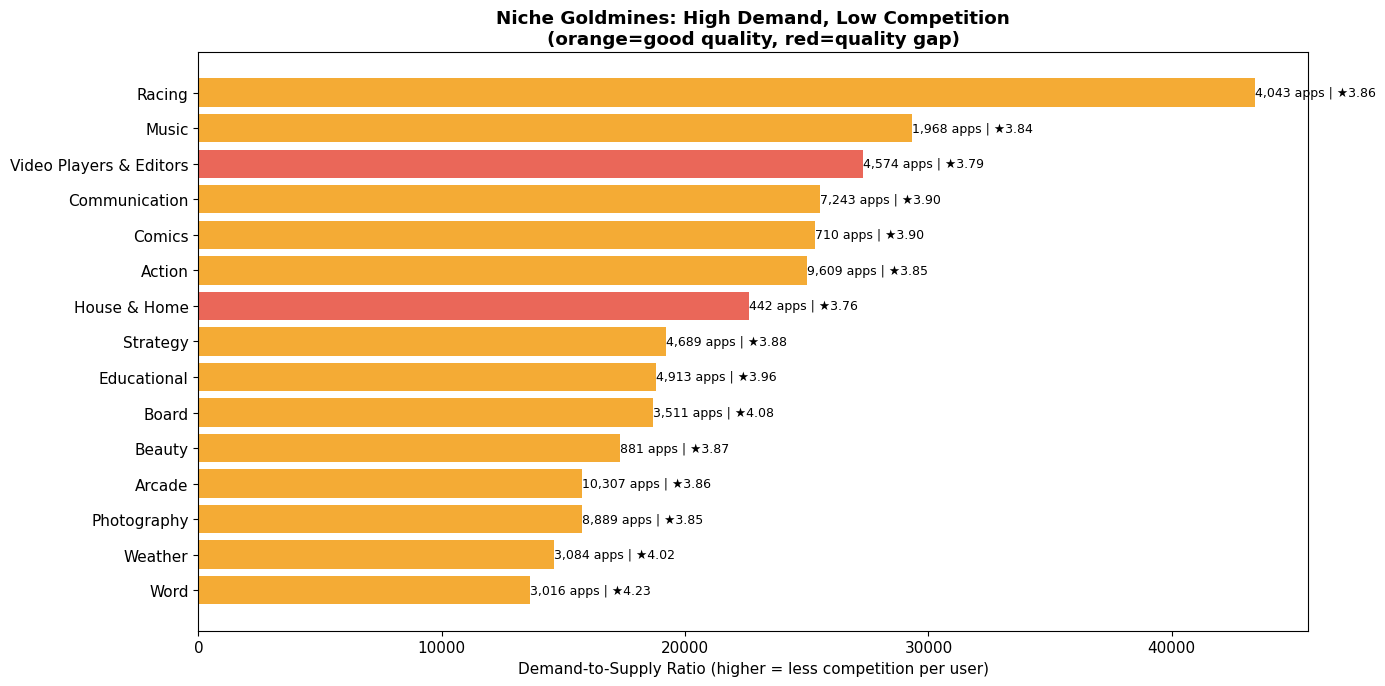

In [7]:
fig, ax = plt.subplots(figsize=(14, 7))
top_niche = niche_sorted.head(15).sort_values('demand_supply_ratio')
colors_n = ['#f39c12' if s >= 3.8 else '#e74c3c' for s in top_niche['avg_score']]
bars = ax.barh(top_niche['genre'], top_niche['demand_supply_ratio'], color=colors_n, alpha=0.85)
for bar, row in zip(bars, top_niche.itertuples()):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
             f'{row.app_count:,} apps | ★{row.avg_score:.2f}',
             va='center', fontsize=9)
ax.set_xlabel('Demand-to-Supply Ratio (higher = less competition per user)')
ax.set_title('Niche Goldmines: High Demand, Low Competition\n(orange=good quality, red=quality gap)', fontweight='bold')
plt.tight_layout()
plt.savefig('p1_niche_goldmines.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 3 — Growing Categories in 2026 (Fresh Demand)
From the 2026 scraped data: categories where new apps are getting installs fast.  
These are categories on the rise right now.

In [8]:
growing = apps26_indie.groupby('genre').agg(
    app_count=('app_id', 'count'),
    avg_score=('score', 'mean'),
    avg_installs=('min_installs', 'mean'),
    total_installs=('min_installs', 'sum'),
    avg_reviews=('reviews', 'mean'),
).reset_index()

growing = growing[growing['app_count'] >= 5]
growing['installs_per_app'] = growing['total_installs'] / growing['app_count']
growing_sorted = growing.sort_values('installs_per_app', ascending=False)

print('=== 2026 INDIE Category Rankings by Installs/App ===')
print(growing_sorted[['genre','app_count','avg_score','installs_per_app','total_installs']].head(25).to_string(index=False))

=== 2026 INDIE Category Rankings by Installs/App ===
                  genre  app_count  avg_score  installs_per_app  total_installs
          Communication         95   4.142339      1.154633e+08    1.096902e+10
                 Arcade         69   4.363681      1.154299e+08    7.964665e+09
                 Racing         45   4.344742      1.102478e+08    4.961150e+09
                 Action        145   4.297908      7.903510e+07    1.146009e+10
                 Casual        130   4.434964      6.190758e+07    8.047986e+09
                  Music         14   4.309698      6.011857e+07    8.416600e+08
        Personalization         54   4.167763      4.097243e+07    2.212511e+09
                 Social        110   4.067996      3.903386e+07    4.293725e+09
               Strategy         87   4.267423      3.844080e+07    3.344350e+09
               Shopping        243   4.319642      3.351606e+07    8.144402e+09
                Weather         11   4.498817      3.296545e+07    

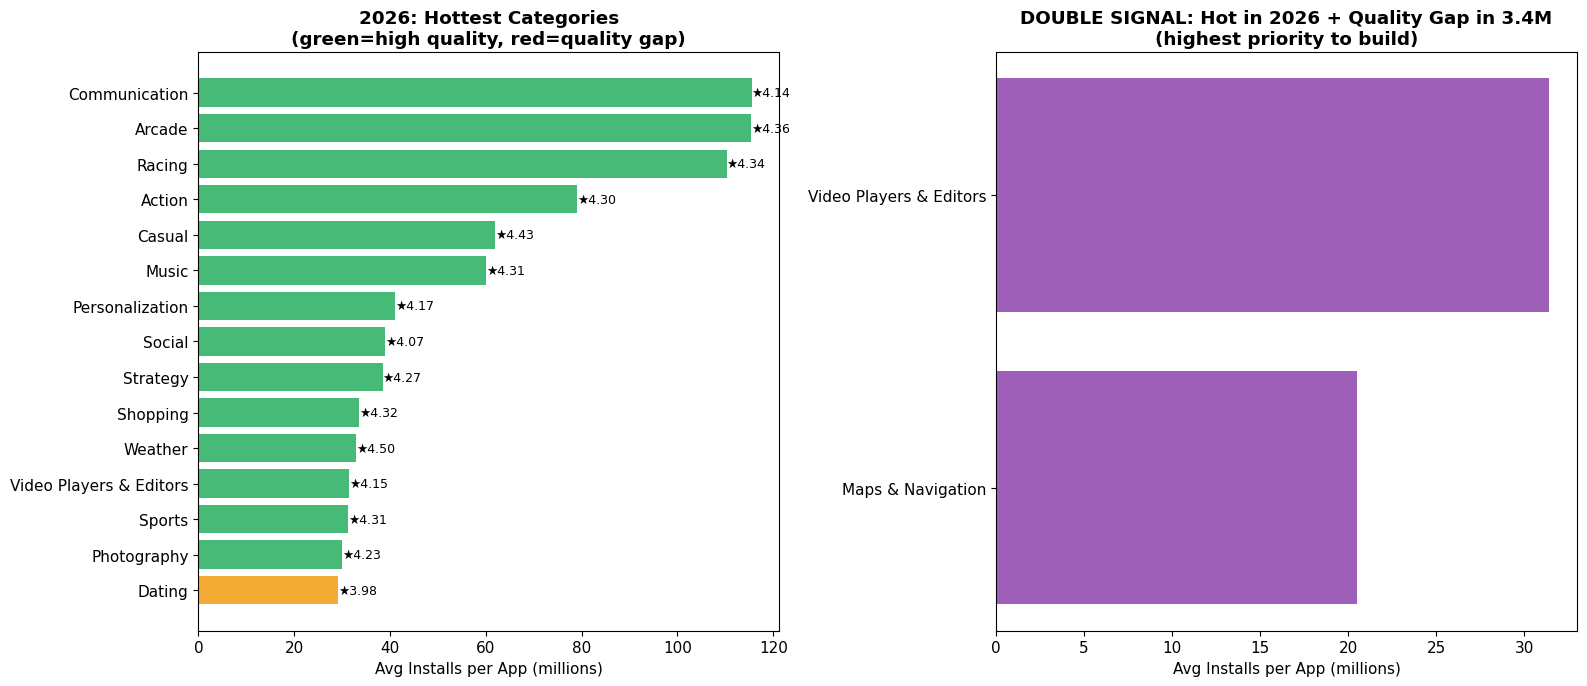

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

ax1 = axes[0]
top_g = growing_sorted.head(15).sort_values('installs_per_app')
c1 = ['#27ae60' if s >= 4.0 else '#f39c12' if s >= 3.5 else '#e74c3c' for s in top_g['avg_score']]
bars = ax1.barh(top_g['genre'], top_g['installs_per_app']/1e6, color=c1, alpha=0.85)
for bar, row in zip(bars, top_g.itertuples()):
    ax1.text(bar.get_width() + 0.02, bar.get_y() + bar.get_height()/2,
             f'★{row.avg_score:.2f}', va='center', fontsize=9)
ax1.set_xlabel('Avg Installs per App (millions)')
ax1.set_title('2026: Hottest Categories\n(green=high quality, red=quality gap)', fontweight='bold')

ax2 = axes[1]
# Cross-reference: categories that are hot in 2026 AND have quality gap in Tapive
hot_2026 = set(growing_sorted.head(20)['genre'].str.strip())
underserved_set = set(underserved['genre'].str.strip())
double_signal = hot_2026 & underserved_set

ds_data = growing_sorted[growing_sorted['genre'].isin(double_signal)]
if len(ds_data) > 0:
    ds_data = ds_data.sort_values('installs_per_app')
    ax2.barh(ds_data['genre'], ds_data['installs_per_app']/1e6, color='#8e44ad', alpha=0.85)
    ax2.set_xlabel('Avg Installs per App (millions)')
    ax2.set_title('DOUBLE SIGNAL: Hot in 2026 + Quality Gap in 3.4M\n(highest priority to build)', fontweight='bold')
else:
    ax2.text(0.5, 0.5, 'No overlap found\n(adjust thresholds)', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Double Signal Categories')

plt.tight_layout()
plt.savefig('p1_growing_categories.png', dpi=150, bbox_inches='tight')
plt.show()

## Signal 4 — Rating Distribution Analysis (No Clear Winner)
In some categories, even the best apps are only 3.5 stars.  
High standard deviation in ratings = no dominant player = open field.

In [10]:
spread = tap_indie.groupby('genre').agg(
    app_count=('appId', 'count'),
    avg_score=('score', 'mean'),
    score_std=('score', 'std'),
    max_score=('score', 'max'),
    p75_score=('score', lambda x: x.quantile(0.75)),
    avg_installs=('minInstalls', 'mean'),
).reset_index()

spread = spread[spread['app_count'] >= 100]
spread['opportunity_score'] = (
    (spread['avg_installs'] / spread['avg_installs'].max()) * 0.5 +
    ((4.5 - spread['p75_score']) / 4.5) * 0.5
)
spread_sorted = spread.sort_values('opportunity_score', ascending=False)

print('=== Indie categories where even top apps are mediocre ===')
print(spread_sorted[['genre','app_count','avg_score','p75_score','avg_installs','opportunity_score']].head(20).to_string(index=False))

=== Indie categories where even top apps are mediocre ===
                  genre  app_count  avg_score  p75_score  avg_installs  opportunity_score
                 Racing       4043   3.861370       4.27  2.760629e+06           0.525556
                 Action       9609   3.846577       4.33  2.452781e+06           0.463132
          Communication       7243   3.897654       4.41  2.173385e+06           0.403640
Video Players & Editors       4574   3.787293       4.40  1.848303e+06           0.345872
                 Arcade      10307   3.856136       4.39  1.601821e+06           0.302341
            Photography       8889   3.849291       4.43  1.485952e+06           0.276911
                 Casual      15155   3.894123       4.43  1.440881e+06           0.268747
            Educational       4913   3.960940       4.34  1.317096e+06           0.256328
               Strategy       4689   3.881139       4.36  1.315150e+06           0.253753
                  Music       1968   3.838

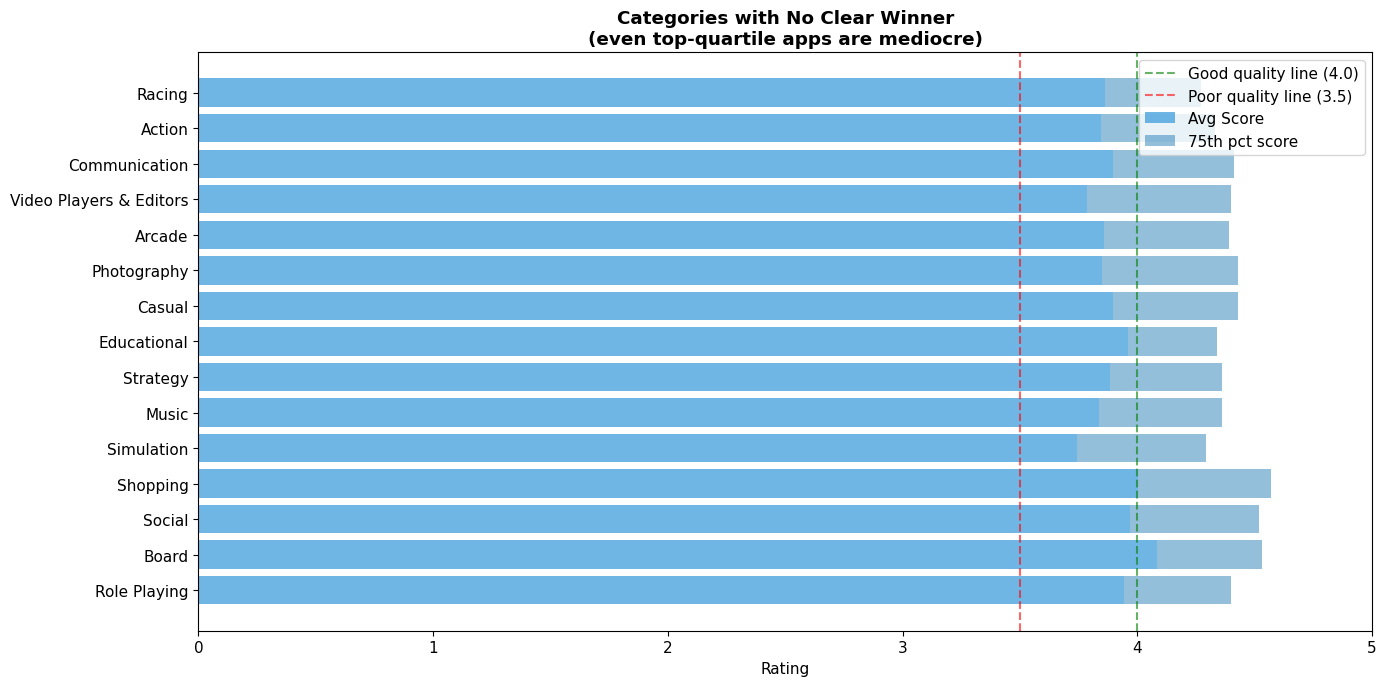

In [11]:
fig, ax = plt.subplots(figsize=(14, 7))
top_spread = spread_sorted.head(15).sort_values('opportunity_score')
x = np.arange(len(top_spread))
ax.barh(top_spread['genre'], top_spread['avg_score'], label='Avg Score', color='#3498db', alpha=0.7)
ax.barh(top_spread['genre'], top_spread['p75_score'] - top_spread['avg_score'],
        left=top_spread['avg_score'], label='75th pct score', color='#2980b9', alpha=0.5)
ax.axvline(4.0, color='green', linestyle='--', alpha=0.6, label='Good quality line (4.0)')
ax.axvline(3.5, color='red', linestyle='--', alpha=0.6, label='Poor quality line (3.5)')
ax.set_xlabel('Rating')
ax.set_title('Categories with No Clear Winner\n(even top-quartile apps are mediocre)', fontweight='bold')
ax.legend()
ax.set_xlim(0, 5)
plt.tight_layout()
plt.savefig('p1_no_clear_winner.png', dpi=150, bbox_inches='tight')
plt.show()

## Final Recommendation — Top Categories to Build Original Apps

In [12]:
# Combine all signals into a single recommendation score
all_genres = set(cat_stats['genre']) | set(growing['genre']) | set(spread['genre'])

rec = cat_stats[['genre','avg_score','avg_installs','app_count']].copy()

# Normalize signals
rec['install_score'] = (rec['avg_installs'] - rec['avg_installs'].min()) / \
                       (rec['avg_installs'].max() - rec['avg_installs'].min())
rec['quality_gap'] = 1 - (rec['avg_score'] - 1) / 4  # lower quality = higher gap score

# 2026 signal — is this category hot right now?
growing_installs = growing.set_index('genre')['installs_per_app'].to_dict()
max_growing = max(growing_installs.values()) if growing_installs else 1
rec['growth_2026'] = rec['genre'].map(
    {g: v/max_growing for g, v in growing_installs.items()}
).fillna(0)

rec['FINAL_SCORE'] = (
    rec['install_score'] * 0.35 +
    rec['quality_gap'] * 0.40 +
    rec['growth_2026'] * 0.25
)

rec_sorted = rec.sort_values('FINAL_SCORE', ascending=False).head(20)

print('\n' + '='*70)
print('TOP CATEGORIES TO BUILD ORIGINAL APPS (ranked by opportunity)')
print('='*70)
for i, row in enumerate(rec_sorted.itertuples(), 1):
    print(f"{i:2}. {row.genre:<30} | Score: {row.FINAL_SCORE:.3f} | "
          f"Avg Rating: {row.avg_score:.2f} | Avg Installs: {row.avg_installs/1e6:.1f}M")


TOP CATEGORIES TO BUILD ORIGINAL APPS (ranked by opportunity)
 1. Racing                         | Score: 0.703 | Avg Rating: 3.86 | Avg Installs: 2.8M
 2. Communication                  | Score: 0.631 | Avg Rating: 3.90 | Avg Installs: 2.2M
 3. Action                         | Score: 0.595 | Avg Rating: 3.85 | Avg Installs: 2.5M
 4. Arcade                         | Score: 0.558 | Avg Rating: 3.86 | Avg Installs: 1.6M
 5. Casual                         | Score: 0.417 | Avg Rating: 3.89 | Avg Installs: 1.4M
 6. Video Players & Editors        | Score: 0.417 | Avg Rating: 3.79 | Avg Installs: 1.8M
 7. Music                          | Score: 0.400 | Avg Rating: 3.84 | Avg Installs: 1.3M
 8. Photography                    | Score: 0.359 | Avg Rating: 3.85 | Avg Installs: 1.5M
 9. Strategy                       | Score: 0.351 | Avg Rating: 3.88 | Avg Installs: 1.3M
10. Social                         | Score: 0.315 | Avg Rating: 3.97 | Avg Installs: 1.1M
11. Shopping                       | 

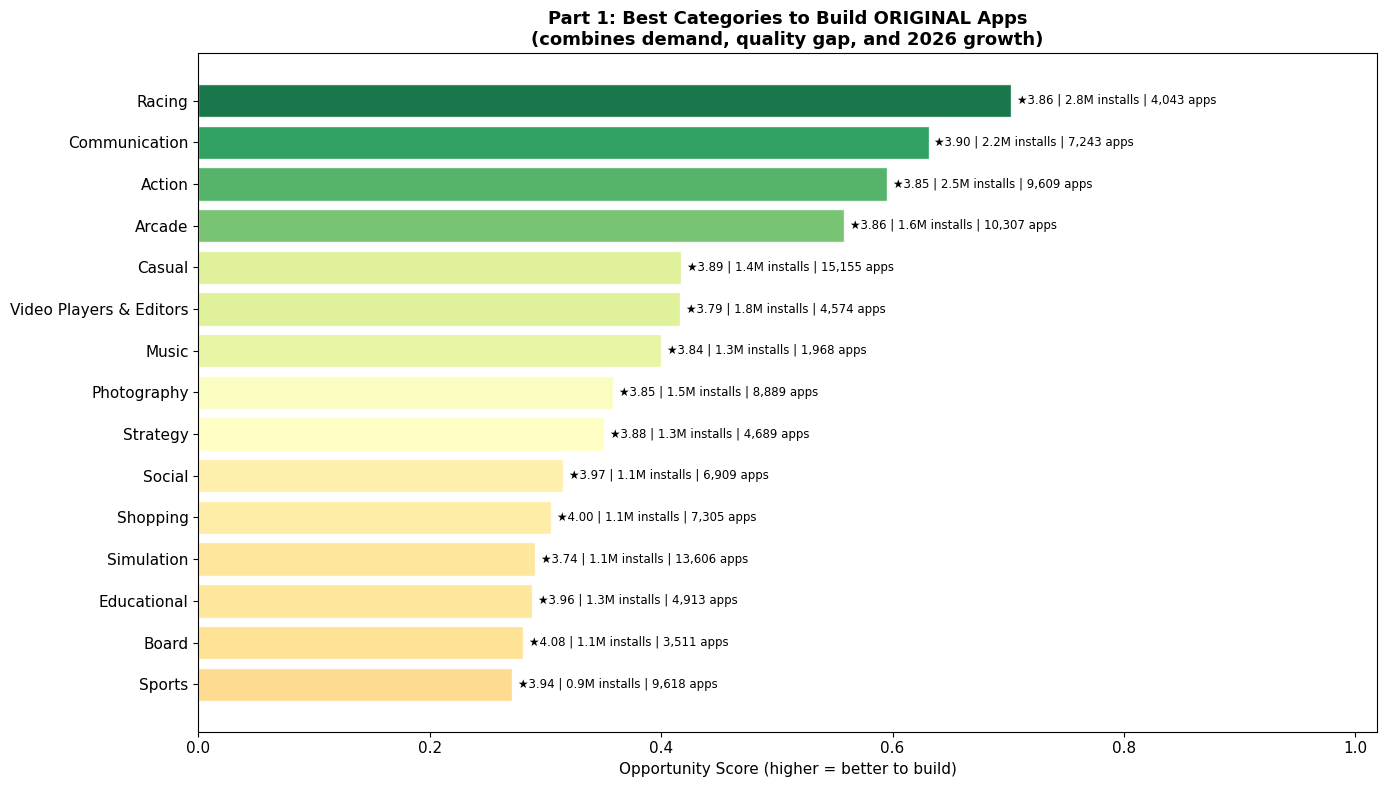


All Part 1 charts saved.


In [13]:
fig, ax = plt.subplots(figsize=(14, 8))
top_rec = rec_sorted.head(15).sort_values('FINAL_SCORE')
bars = ax.barh(top_rec['genre'], top_rec['FINAL_SCORE'],
               color=plt.cm.RdYlGn(top_rec['FINAL_SCORE'] / top_rec['FINAL_SCORE'].max()),
               alpha=0.9, edgecolor='white')
for bar, row in zip(bars, top_rec.itertuples()):
    ax.text(bar.get_width() + 0.005, bar.get_y() + bar.get_height()/2,
             f'★{row.avg_score:.2f} | {row.avg_installs/1e6:.1f}M installs | {row.app_count:,} apps',
             va='center', fontsize=8.5)
ax.set_xlabel('Opportunity Score (higher = better to build)')
ax.set_title('Part 1: Best Categories to Build ORIGINAL Apps\n'
             '(combines demand, quality gap, and 2026 growth)', fontweight='bold', fontsize=13)
ax.set_xlim(0, top_rec['FINAL_SCORE'].max() * 1.45)
plt.tight_layout()
plt.savefig('p1_final_recommendations.png', dpi=150, bbox_inches='tight')
plt.show()
print('\nAll Part 1 charts saved.')